In [2]:
import pandas as pd
import os

# Sizning kompyuteringizdagi aniq manzil
file_path = r'C:\Users\TEMUR SHIRINBOYEV\Downloads\DA_and_ML_Project_2\data\ecommerce_sales_data.csv'

# Fayl borligini tekshiramiz
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # Sanani formatlash (Keyingi tahlillar uchun shart)
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], dayfirst=True)
    print("Tabriklayman! Fayl muvaffaqiyatli yuklandi ✅")
    print(df.head())
else:
    print("Xato: Fayl hali ham topilmadi. Papka nomini yoki fayl nomini qayta tekshiring ❌")

Tabriklayman! Fayl muvaffaqiyatli yuklandi ✅
                               Order ID Product Name       Category   Price  \
0  261e3740-c0e9-42b1-bf87-881ac950fa3a     audience  Home & Garden  766.85   
1  0b332b34-46dc-4eaf-a808-fec7e97ffbc6         such       Clothing  331.42   
2  432e0b36-724d-4521-85ae-f66db8af8105         read       Clothing  708.10   
3  ca20fb08-5c65-43b8-9577-3fa49913f93b        skill    Electronics  774.09   
4  1dce189c-8c60-455f-a6f2-69bb2cb71539         cold    Electronics  397.22   

   Quantity  Total Sales                           Customer ID  Customer Age  \
0         4      3067.40  81af1248-afff-46ee-a091-81cf33d0d957            39   
1         4      1325.68  f3f3f4ac-7ad0-4362-9134-383096d16ac8            21   
2        10      7081.00  c4fc4269-3c1d-4b6b-ad23-d437c328d63f            27   
3         2      1548.18  578e2d1a-d92a-449d-8eeb-b704110b2975            51   
4         1       397.22  dc6ed196-0874-46bd-bbb9-c5534f619349            45   


C:\Users\TEMUR SHIRINBOYEV\AppData\Local\Temp\ipykernel_12984\2035404986.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='viridis')


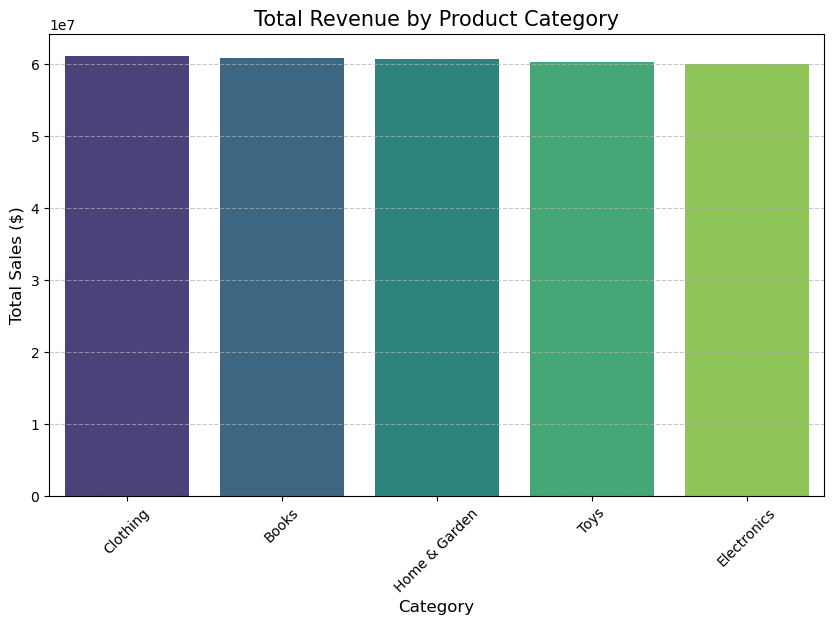

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kategoriyalar bo'yicha guruhlash va daromadni hisoblash
cat_revenue = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='viridis')
plt.title('Total Revenue by Product Category', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretation: 
# 'Clothing' va 'Books' eng ko'p daromad keltiruvchi sohalar ekanligi ko'rinmoqda.

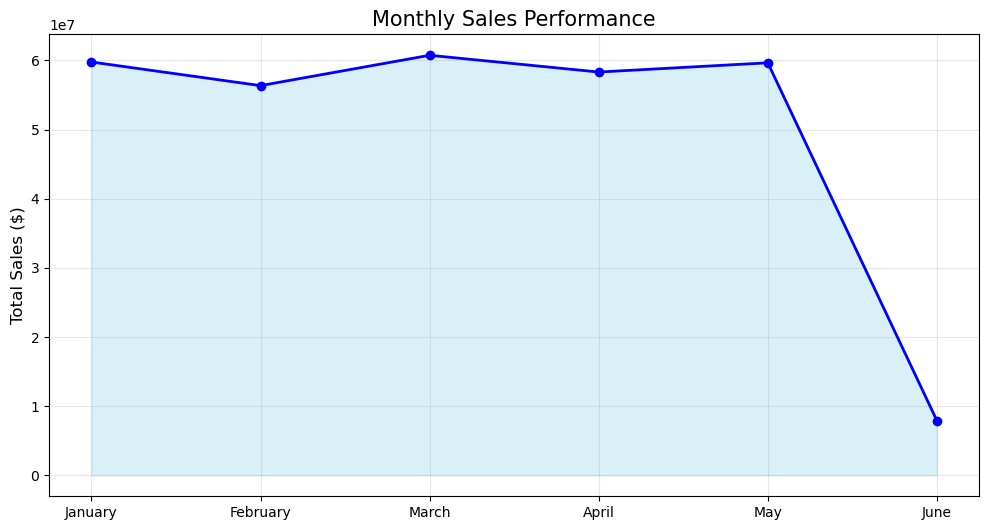

In [4]:
# Oylik savdo hajmini tahlil qilish
df['Month'] = df['Purchase Date'].dt.month_name()
monthly_sales = df.groupby('Month')['Total Sales'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June'
]).dropna()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='b', linewidth=2)
plt.fill_between(monthly_sales.index, monthly_sales.values, color='skyblue', alpha=0.3)
plt.title('Monthly Sales Performance', fontsize=15)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation:
# Mart oyida savdo hajmi eng yuqori nuqtaga chiqqanini kuzatishimiz mumkin.

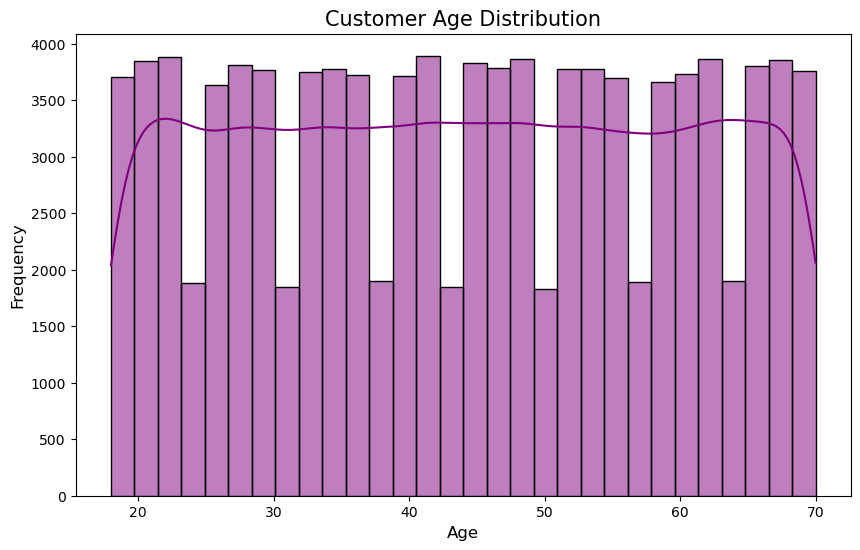

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Customer Age', bins=30, kde=True, color='purple')
plt.title('Customer Age Distribution', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Interpretation:
# Do'konimizning asosiy xaridorlari 20 dan 50 yoshgacha bo'lgan faol qatlamdir.

In [ ]:
#ML 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import root_mean_squared_error, accuracy_score, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("Kutubxonalar yuklandi! ✅")

Kutubxonalar yuklandi! ✅


In [11]:
# Kerakli ustunlarni nusxalab olamiz
ml_df = df[['Category', 'Price', 'Quantity', 'Customer Age', 'Customer Gender', 'Total Sales']].copy()

# LabelEncoder yordamida matnlarni raqamga o'giramiz
encoder = LabelEncoder()
ml_df['Category_Encoded'] = encoder.fit_transform(ml_df['Category'])
ml_df['Gender_Encoded'] = encoder.fit_transform(ml_df['Customer Gender'])

# Endi ML uchun faqat raqamli ustunlarni ajratamiz
X = ml_df[['Category_Encoded', 'Price', 'Quantity', 'Customer Age', 'Gender_Encoded']]
y_reg = ml_df['Total Sales']      # Regressiya uchun maqsad (Summani bashorat qilish)
y_clf = ml_df['Category_Encoded'] # Klassifikatsiya uchun maqsad (Kategoriyani bashorat qilish)

print("Ma'lumotlar ML formatiga keltirildi! 🛠️")

Ma'lumotlar ML formatiga keltirildi! 🛠️


In [12]:
# Ma'lumotni bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Modelni yaratish va o'qitish
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

# Bashorat va baholash
y_pred_reg = reg_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print(f"--- Regression Natijalari ---")
print(f"R2 Score (Aniqlik): {r2:.4f}")
print(f"RMSE (Xatolik darajasi): {rmse:.2f}")

--- Regression Natijalari ---
R2 Score (Aniqlik): 1.0000
RMSE (Xatolik darajasi): 0.55


In [13]:
# Klassifikatsiya uchun ma'lumotni bo'lish (Xarid summasidan tashqari ustunlar bilan)
X_clf = ml_df[['Price', 'Customer Age', 'Gender_Encoded']] 
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Modelni o'qitish
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_c, y_train_c)

# Bashorat va baholash
y_pred_clf = clf_model.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_clf)

print(f"\n--- Classification Natijalari ---")
print(f"Model Accuracy (Aniqlik): {acc:.4f}")


--- Classification Natijalari ---
Model Accuracy (Aniqlik): 0.1960
